<a href="https://colab.research.google.com/github/nikhithacom2007-cmyk/codealphainternship/blob/main/codealphatask4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Using UCI Heart Disease Dataset
url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nTarget Distribution:")
print(df['target'].value_counts())

Dataset Shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



Target Distribution:
target
1    165
0    138
Name: count, dtype: int64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Missing Values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


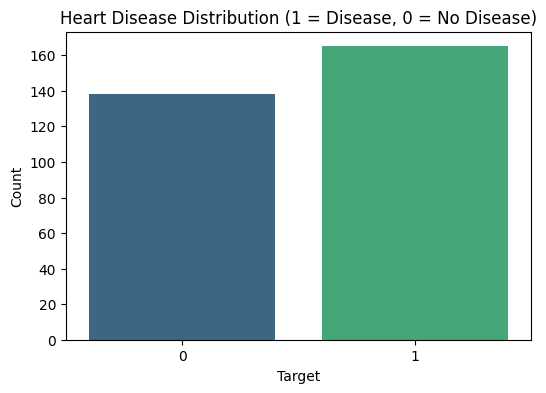

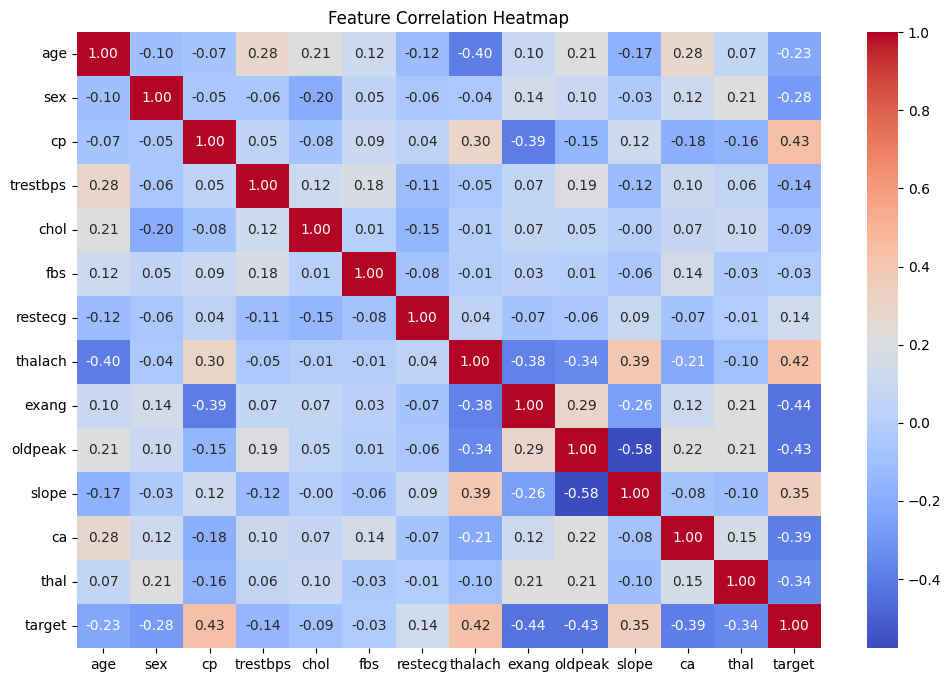

In [3]:
# Basic Information
df.info()
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistical Summary:")
display(df.describe())

# Visualizations
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Heart Disease Distribution (1 = Disease, 0 = No Disease)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [4]:
X = df.drop('target', axis=1)
y = df['target']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data Preprocessed")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

✅ Data Preprocessed
Training samples: 242
Testing samples: 61


In [5]:
def evaluate_model(model, X_test, y_test, model_name, scaled=False):
    if scaled:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    print(f"\n{'='*20} {model_name} {'='*20}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    if y_pred_proba is not None:
        print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return accuracy_score(y_test, y_pred)


==================== Logistic Regression ====================
Accuracy: 0.8033
ROC AUC Score: 0.8690

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



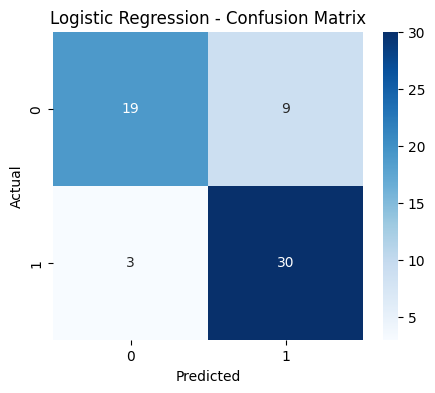


==================== Random Forest ====================
Accuracy: 0.8197
ROC AUC Score: 0.9080

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.64      0.77        28
           1       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61



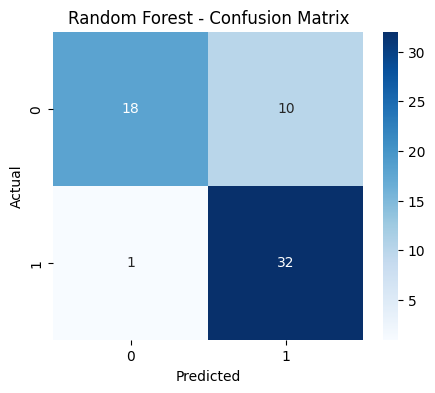


==================== Support Vector Machine ====================
Accuracy: 0.8197
ROC AUC Score: 0.8831

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.68      0.78        28
           1       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61



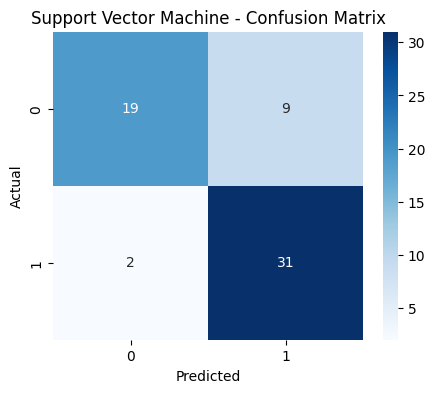


==================== XGBoost ====================
Accuracy: 0.7869
ROC AUC Score: 0.8463

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.61      0.72        28
           1       0.74      0.94      0.83        33

    accuracy                           0.79        61
   macro avg       0.82      0.77      0.78        61
weighted avg       0.81      0.79      0.78        61



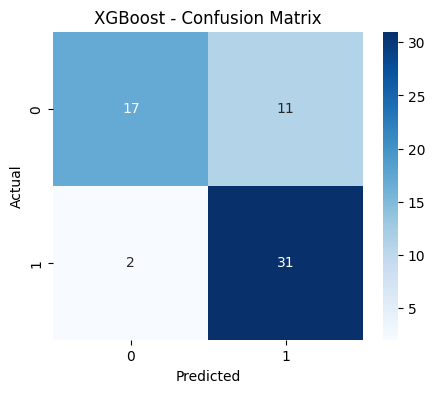

In [6]:
results = {}

# 1. Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
results['Logistic Regression'] = evaluate_model(lr, X_test_scaled, y_test, "Logistic Regression", scaled=True)

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
results['Random Forest'] = evaluate_model(rf, X_test, y_test, "Random Forest")

# 3. SVM
svm = SVC(probability=True, random_state=42, kernel='rbf')
svm.fit(X_train_scaled, y_train)
results['SVM'] = evaluate_model(svm, X_test_scaled, y_test, "Support Vector Machine", scaled=True)

# 4. XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='logloss', n_estimators=200)
xgb.fit(X_train, y_train)
results['XGBoost'] = evaluate_model(xgb, X_test, y_test, "XGBoost")

🏆 Model Performance Comparison:


,Model,Accuracy
1,Random Forest,0.819672
2,SVM,0.819672
0,Logistic Regression,0.803279
3,XGBoost,0.786885


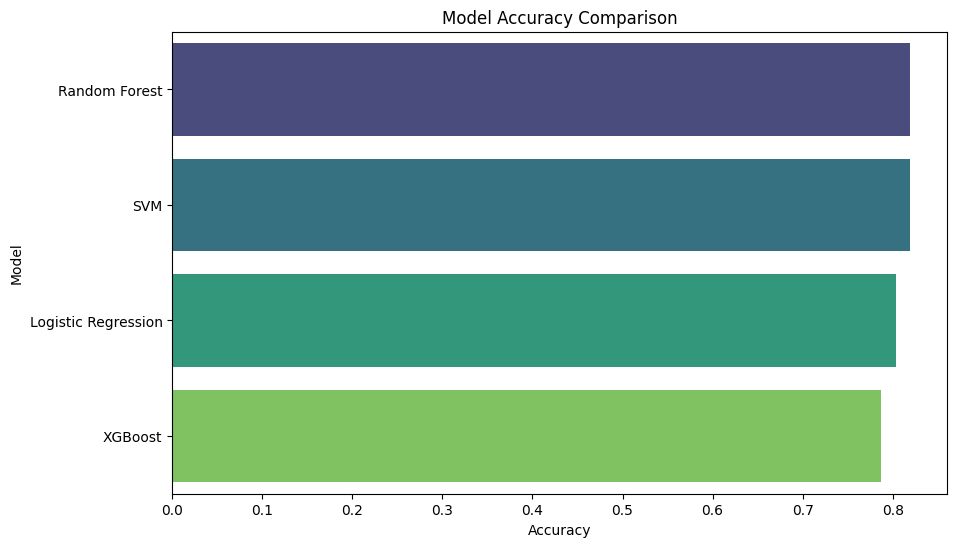

In [7]:
# Model Comparison
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': list(results.values())
}).sort_values(by='Accuracy', ascending=False)

print("🏆 Model Performance Comparison:")
display(comparison)

# Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=comparison, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.show()

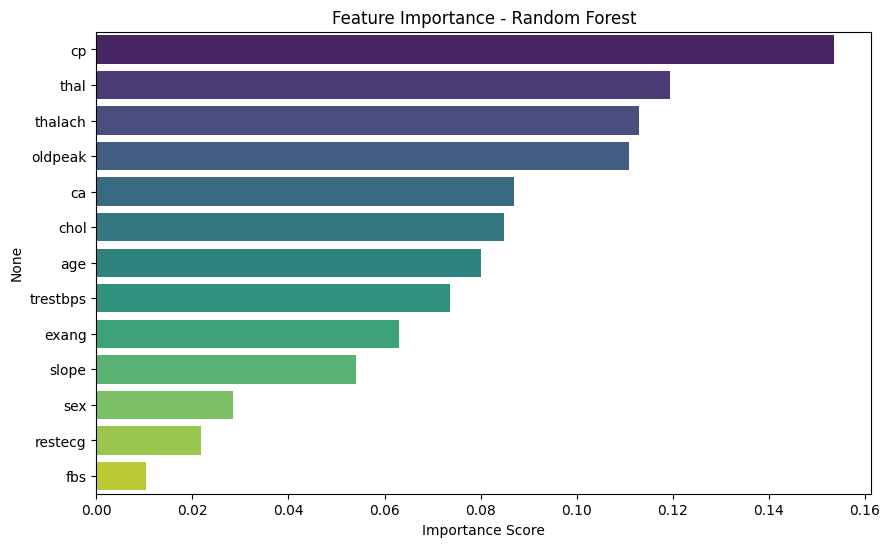

Top 5 Important Features:
cp         0.153619
thal       0.119375
thalach    0.113028
oldpeak    0.110831
ca         0.086868
dtype: float64


In [8]:
# Feature Importance using Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.show()

print("Top 5 Important Features:")
print(importances.head())


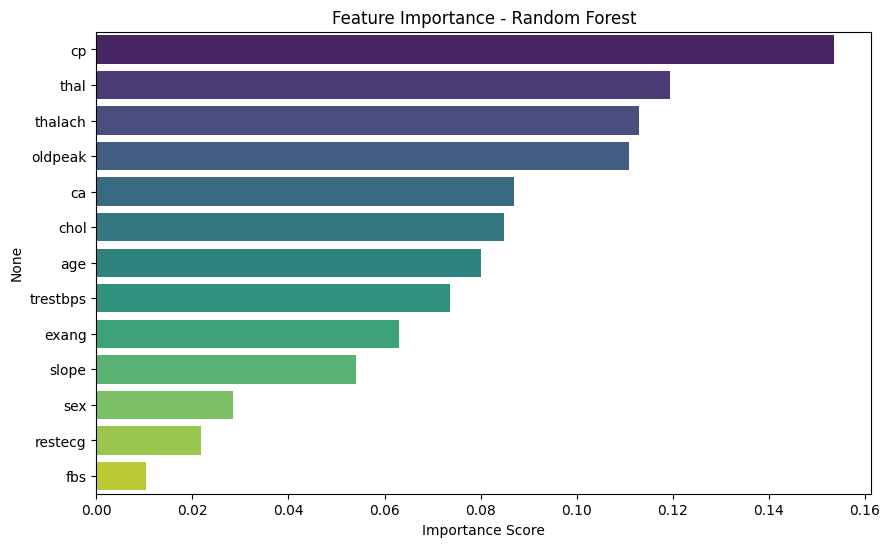

Top 5 Important Features:
cp         0.153619
thal       0.119375
thalach    0.113028
oldpeak    0.110831
ca         0.086868
dtype: float64


In [9]:
# Feature Importance using Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.show()

print("Top 5 Important Features:")
print(importances.head())

In [15]:
import pandas as pd

# Example Prediction
sample = pd.DataFrame({
    'age': [63], 'sex': [1], 'cp': [3], 'trestbps': [145], 'chol': [233],
    'fbs': [1], 'restecg': [0], 'thalach': [150], 'exang': [0],
    'oldpeak': [2.3], 'slope': [0], 'ca': [0], 'thal': [1]
})

sample_scaled = scaler.transform(sample)

# Assign the best performing model (e.g., SVM, as it was trained on scaled data and performed well)
best_model = svm

prediction = best_model.predict(sample_scaled)[0]
prob = best_model.predict_proba(sample_scaled)[0][1]

print(f"Prediction: {'Heart Disease' if prediction == 1 else 'No Heart Disease'}")
print(f"Probability of Disease: {prob:.2%}")

Prediction: Heart Disease
Probability of Disease: 64.63%
